# The ANNNI phase diagram under two classes of error, and what each one does to a phase boundary

**QSITE 2026 Quantum Coalition, Scientific Track. Matthew Stanley Leibel, TrueLoop Compute (NEOTECH Inc.)**

This notebook maps the phase diagram of the 1D axial next-nearest-neighbour Ising (ANNNI) model on $N=8$ qubits (with an $N=12$ extension), prepares every ground state with a variational circuit, and then studies how errors distort the phase boundaries. It answers the track's question about depolarizing noise at $p = 0.01$ and $p = 0.05$, and then adds the error class the handout leaves out, coherent calibration drift, because on a real processor both are present and they do different things to a boundary.

**The finding in one line:** depolarizing noise is *amplitude loss*, uniform and sign-preserving, which a reference-rescaled observable undoes until the signal dies; coherent drift is *shape distortion*, signed and first-order, which no rescaling fixes but which an in-band maintenance layer removes at five probe circuits per cycle.

**How to read this notebook.** Every method is implemented in PennyLane and demonstrated live on representative points. The full 15x15 grids take about 12 minutes on `default.mixed` and were computed with the same code (`code/pl_depol.py`) and cached in `data/`; set `RECOMPUTE = True` to regenerate everything. A numpy density-matrix simulator (`code/sim.py`) is used only to accelerate the drift study and is validated against PennyLane's `default.mixed` to $10^{-12}$ in Section 4. Environment: Python 3.12, PennyLane 0.45.1 (the track pins 0.44.1; only standard APIs are used).

In [1]:
import sys, os, time, pickle, subprocess, warnings, numpy as np, pennylane as qml, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
sys.path.insert(0, "code"); sys.path.insert(0, "starter_kit")
try:
    import trueloop
except ImportError:                                   # the maintenance layer: evaluation build shipped in trueloop/ (pure Python, no dependencies)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "trueloop/trueloop-3.1.0rc90-py3-none-any.whl"], check=True); import trueloop
RECOMPUTE = False                      # True: regenerate every cached grid from scratch (VQE ~6 min, PennyLane noisy grids ~12 min)
N, LAYERS = 8, 4
KAPPAS, HS = np.linspace(0.0, 1.0, 15), np.linspace(0.05, 2.0, 15)
from annni import build_annni_hamiltonian
from reference import ising_transition, kt_transition
import sim, hva
print("PennyLane", qml.__version__, "| grid", len(KAPPAS), "x", len(HS), "| N =", N)

PennyLane 0.45.1 | grid 15 x 15 | N = 8


## 1. Hamiltonian
$H = -\sum_i Z_i Z_{i+1} + \kappa \sum_i Z_i Z_{i+2} - h \sum_i X_i$, periodic. Built with the starter kit's `build_annni_hamiltonian` and checked against an independent dense construction and its ground state.

In [2]:
H_pl = build_annni_hamiltonian(N, kappa=0.3, h=0.6)
H_dense = sim.annni_matrix(N, 0.3, 0.6)
M_pl = qml.matrix(H_pl, wire_order=range(N))
E0, psi0 = sim.exact_ground(N, 0.3, 0.6)
print("starter-kit Hamiltonian vs dense construction: max |diff| = %.1e" % np.max(np.abs(M_pl - H_dense)))
print("exact ground energy at (kappa, h) = (0.3, 0.6): E0 = %.5f" % E0)

starter-kit Hamiltonian vs dense construction: max |diff| = 0.0e+00
exact ground energy at (kappa, h) = (0.3, 0.6): E0 = -7.02246


## 2. Ansatz: Hamiltonian-variational circuit
From $|+\rangle^{\otimes N}$, four layers of $e^{-i g_1 \sum ZZ_{nn}}\, e^{-i g_2 \sum ZZ_{nnn}}\, e^{-i b \sum X}$: 12 parameters, real ground states, and the gate structure a device would run (each $RZZ$ is CNOT-RZ-CNOT, 128 CNOTs). The PennyLane circuit below is the one used for every noisy evaluation; the numpy implementation in `code/hva.py` is the same unitary with an adjoint gradient, used for the optimization. Their states agree to machine precision.

In [3]:
from hva import _PAIRS
dev_pure = qml.device("default.qubit", wires=N)

def hva_circuit(params, p=0.0, eps=None, delta=None):
    # HVA circuit. p: depolarizing after every CNOT target (starter-kit convention). eps/delta: coherent angle errors.
    prm = np.asarray(params).reshape(LAYERS, 3)
    eps = np.zeros(N) if eps is None else eps; delta = np.zeros(2 * N) if delta is None else delta
    for i in range(N): qml.Hadamard(wires=i)
    for l in range(LAYERS):
        g1, g2, b = prm[l]
        for k, (i, j) in enumerate(_PAIRS):
            qml.CNOT(wires=[i, j])
            if p > 0: qml.DepolarizingChannel(p, wires=j)
            qml.RZ(2 * (g1 if k < N else g2) * (1 + delta[k]), wires=j)
            qml.CNOT(wires=[i, j])
            if p > 0: qml.DepolarizingChannel(p, wires=j)
        for i in range(N): qml.RX(2 * b * (1 + eps[i]), wires=i)

@qml.qnode(dev_pure)
def state_pl(params): hva_circuit(params); return qml.state()

grid = {}
for f in ("0_4", "4_8", "8_12", "12_15"): grid.update(pickle.load(open("data/hva_%s.pkl" % f, "rb")))
prm = grid[(4, 3)]["params"]
psi_pl, psi_np = np.array(state_pl(prm)), hva.hva_state(prm)
print("PennyLane state vs numpy state: fidelity = %.12f" % abs(np.vdot(psi_pl, psi_np)) ** 2)
print(qml.draw(state_pl, max_length=120)(prm).split("\n")[0][:118], "...")

PennyLane state vs numpy state: fidelity = 1.000000000000
0: ──H─╭●───────────╭●───────────────────────────────────────────────────────────────────────────────────────────── ·· ...


## 3. Ground-state preparation by VQE, checked against exact diagonalization
L-BFGS on the exact energy with adjoint gradients, warm-started down the field from the paramagnet, where the ground state is a product state and the circuit is exact. One point is optimized live in PennyLane below; the full grid (cached) used `code/hva.py`.

In [4]:
from scipy.optimize import minimize
from pennylane import numpy as pnp
H_036 = build_annni_hamiltonian(N, kappa=0.3, h=0.6)
@qml.qnode(dev_pure, diff_method="adjoint")
def energy_pl(params):
    hva_circuit(params); return qml.expval(H_036)
grad_pl = qml.grad(energy_pl)
x0 = np.array(grid[(4, 4)]["params"]) + 0.05                              # warm start from a neighbouring point, nudged
t0 = time.perf_counter()
r = minimize(lambda x: float(energy_pl(pnp.array(x, requires_grad=True))), x0, jac=lambda x: np.array(grad_pl(pnp.array(x, requires_grad=True))), method="L-BFGS-B", options={"maxiter": 200})
print("live PennyLane VQE at (0.3, 0.6): E = %.5f vs exact %.5f (relative error %.1e), %d evaluations, %.1f s" % (r.fun, E0, (r.fun - E0) / abs(E0), r.nfev, time.perf_counter() - t0))
if RECOMPUTE:
    import subprocess; [subprocess.run([sys.executable, "code/hva.py", a, b], check=True) for a, b in (("0", "4"), ("4", "8"), ("8", "12"), ("12", "15"))]
dE = np.array([[(grid[(ki, hi)]["E"] - grid[(ki, hi)]["Eg"]) / abs(grid[(ki, hi)]["Eg"]) for hi in range(15)] for ki in range(15)])
dz = np.array([[abs(grid[(ki, hi)]["zz2"] - grid[(ki, hi)]["zz2_ed"]) for hi in range(15)] for ki in range(15)])
print("full grid (cached): relative energy error median %.1e, max %.1e | correlator error median %.3f, 95th pct %.3f, max %.3f" % (np.median(dE), dE.max(), np.median(dz), np.percentile(dz, 95), dz.max()))
ki, hi = int(np.argmax(dz) // 15), int(np.argmax(dz) % 15); H = sim.annni_matrix(N, KAPPAS[ki], HS[hi]); w, v = np.linalg.eigh(H)
print("the worst point is (kappa=%.2f, h=%.2f), on the analytic KT line (%.2f): exact ground state C2 = %.2f, but three states within %.3f of it have C2 = %s; the variational state (%.3f above E0) lands in that manifold. A finite-size boundary degeneracy, not an optimizer failure." % (
    KAPPAS[ki], HS[hi], kt_transition(KAPPAS[ki]), sim.observables_psi(v[:, 0], N)["zz_next"], w[3] - w[0], [round(sim.observables_psi(v[:, j], N)["zz_next"], 2) for j in (1, 2, 3)], grid[(ki, hi)]["E"] - w[0]))

live PennyLane VQE at (0.3, 0.6): E = -7.02234 vs exact -7.02246 (relative error 1.7e-05), 107 evaluations, 15.6 s
full grid (cached): relative energy error median 3.9e-05, max 2.2e-02 | correlator error median 0.000, 95th pct 0.043, max 0.615
the worst point is (kappa=0.57, h=0.19), on the analytic KT line (0.19): exact ground state C2 = -0.32, but three states within 0.063 of it have C2 = [-0.95, -0.95, -0.97]; the variational state (0.049 above E0) lands in that manifold. A finite-size boundary degeneracy, not an optimizer failure.


## 4. The clean phase diagram (required image 1)
The observable is the next-nearest-neighbour correlator $C_2 = \frac{1}{N}\sum_i \langle Z_i Z_{i+2}\rangle$: $+1$ in the ferromagnet, $-1$ in the antiphase ($\uparrow\uparrow\downarrow\downarrow$), small in the paramagnet. It is symmetry-safe at finite size, unlike single-site magnetization or products of single-bond expectations, which vanish on the symmetric ground state. Classification thresholds are fixed once from the clean diagram on the analytic lines and reused for every noisy arm. The $\kappa = 0.5$ column, the multicritical point where the ferromagnet and antiphase meet at $h = 0$, has no ordered reference and is treated separately.

In [5]:
PL = np.load("data/pennylane_grid.npz")
zz_clean = PL["p0"]                                 # computed on default.mixed at p=0 (code/pl_depol.py); equals default.qubit to 1e-15
kk = np.linspace(0.01, 0.99, 300)
def ising_line(k): return ising_transition(k)
def kt_line(k): return kt_transition(k)
from analyze2 import thresholds, boundaries, classify, renorm, crossing
T_F, T_A = thresholds(zz_clean); hf0, ha0 = boundaries(zz_clean, T_F, T_A)
print("thresholds on the analytic lines: ferro %.3f, antiphase %.3f" % (T_F, T_A))
def phase_panel(ax, z, title, hf=None, ha=None):
    K, Hm = np.meshgrid(KAPPAS, HS, indexing="ij")
    im = ax.pcolormesh(K, Hm, z, cmap="coolwarm", vmin=-1, vmax=1, shading="auto")
    ax.plot(kk, ising_line(kk), "k--", lw=1.2, label="Ising line (analytic)"); ax.plot(kk, kt_line(kk), "k:", lw=1.5, label="KT line (analytic)")
    if hf is not None: ax.plot(KAPPAS, hf, "ko-", ms=4, lw=1.2, label="measured ferro/para boundary"); ax.plot(KAPPAS, ha, "ks-", ms=4, lw=1.2, label="measured antiphase/para boundary")
    ax.set_xlabel(r"$\kappa$"); ax.set_ylabel(r"$h$"); ax.set_ylim(HS[0], HS[-1]); ax.set_title(title, fontsize=11); return im
fig, ax = plt.subplots(figsize=(7.2, 5.4)); im = phase_panel(ax, zz_clean, r"ANNNI N=8, clean ($p=0$): $\langle Z_i Z_{i+2}\rangle$", hf0, ha0)
plt.colorbar(im, ax=ax, label=r"$C_2$"); ax.legend(fontsize=8, loc="upper right"); plt.tight_layout(); plt.savefig("figures/phase_diagram_p0.png", dpi=150); plt.show()
ki3, ki7 = int(np.argmin(abs(KAPPAS - 0.3))), int(np.argmin(abs(KAPPAS - 0.7)))
print("ferro->para boundary at kappa=%.2f: measured h*=%.3f, analytic Ising line %.3f | antiphase->para at kappa=%.2f: measured %.3f, analytic KT line %.3f" % (KAPPAS[ki3], hf0[ki3], ising_line(KAPPAS[ki3]), KAPPAS[ki7], ha0[ki7], kt_line(KAPPAS[ki7])))

thresholds on the analytic lines: ferro 0.559, antiphase 0.825


ferro->para boundary at kappa=0.29: measured h*=0.512, analytic Ising line 0.473 | antiphase->para at kappa=0.71: measured 0.381, analytic KT line 0.381


## 5. Depolarizing noise (required images 2 and 3)
`DepolarizingChannel(p)` on the target after every CNOT, the starter kit's convention, on `default.mixed`. The cached full grids were computed by the qnode below (`code/pl_depol.py`); one point is recomputed live here and compared, and the fast numpy simulator used later is checked against the same qnode at the same time.

In [6]:
dev_mixed = qml.device("default.mixed", wires=N)
@qml.qnode(dev_mixed)
def zz2_mixed(params, p, eps=None, delta=None):
    hva_circuit(params, p=p, eps=eps, delta=delta); return [qml.expval(qml.PauliZ(i) @ qml.PauliZ((i + 2) % N)) for i in range(N)]
t0 = time.perf_counter(); live = float(np.mean(zz2_mixed(prm, 0.01))); el = time.perf_counter() - t0
print("live default.mixed at (0.29, 0.47), p=0.01: C2 = %.4f (cached %.4f), %.1f s per point" % (live, PL["p001"][4, 3], el))
rho_fast = sim.observables_rho(__import__("noise_study").hva_rho(prm, 0.01, np.zeros(N), np.zeros(2 * N)), N)["zz_next"]
print("fast numpy density-matrix simulator at the same point: %.4f  (full-grid agreement with PennyLane: max |diff| 2e-12)" % rho_fast)
if RECOMPUTE:
    import subprocess; [subprocess.run([sys.executable, "code/pl_depol.py", str(a), str(b)], check=True) for a, b in ((0, 60), (60, 115), (115, 170), (170, 225))]
zz_p001, zz_p005 = PL["p001"], PL["p005"]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, z, p, fn in ((axes[0], zz_p001, 0.01, "figures/phase_diagram_p0.01.png"), (axes[1], zz_p005, 0.05, "figures/phase_diagram_p0.05.png")):
    hf, ha = boundaries(z, T_F, T_A); im = phase_panel(ax, z, r"depolarizing $p=%.2f$: $\langle Z_i Z_{i+2}\rangle$" % p, hf, ha)
    f2, a2 = plt.subplots(figsize=(7.2, 5.4)); i2 = phase_panel(a2, z, r"ANNNI N=8, depolarizing $p=%.2f$ after every CNOT: $\langle Z_i Z_{i+2}\rangle$" % p, hf, ha); plt.colorbar(i2, ax=a2, label=r"$C_2$"); a2.legend(fontsize=8, loc="upper right"); f2.tight_layout(); f2.savefig(fn, dpi=150); plt.close(f2)
plt.colorbar(im, ax=axes[1], label=r"$C_2$"); plt.tight_layout(); plt.show()
amp = [np.mean(np.abs(z[:, 0])) for z in (zz_clean, zz_p001, zz_p005)]
print("signal amplitude at h=0.05 (deep ordered): clean %.3f | p=0.01 %.3f | p=0.05 %.3f" % tuple(amp))
print("deep ferromagnet (kappa=0, h=0.05): clean %.3f -> p=0.01 %.3f | deep antiphase (kappa=1, h=0.05): clean %.3f -> p=0.01 %.3f" % (zz_clean[0, 0], zz_p001[0, 0], zz_clean[-1, 0], zz_p001[-1, 0]))

live default.mixed at (0.29, 0.47), p=0.01: C2 = 0.2953 (cached 0.2953), 1.8 s per point
fast numpy density-matrix simulator at the same point: 0.2953  (full-grid agreement with PennyLane: max |diff| 2e-12)


signal amplitude at h=0.05 (deep ordered): clean 0.923 | p=0.01 0.483 | p=0.05 0.049
deep ferromagnet (kappa=0, h=0.05): clean 0.999 -> p=0.01 0.373 | deep antiphase (kappa=1, h=0.05): clean -0.999 -> p=0.01 -0.603


### 5.1 What depolarizing does: amplitude loss, and a mitigation that recovers the boundary
With a threshold calibrated on the clean diagram, both noisy diagrams lose every ordered point, because the correlator is scaled down everywhere. The scaling is nearly uniform, so a reference-rescaled observable, each column divided by its value at $h = 0.05$ (the standard measure-the-decay mitigation), recovers the boundaries at $p=0.01$. At $p=0.05$ the signal is 5% of clean and nothing recovers it. The rescaling over-corrects slightly, because the deep-ordered cat-like states are more entangled and lose more than states near the boundary, so the recovered boundaries sit slightly outside the clean ones.

In [7]:
Tn_F, Tn_A = thresholds(renorm(zz_clean)); hfn0, han0 = boundaries(renorm(zz_clean), Tn_F, Tn_A); refn = classify(renorm(zz_clean), Tn_F, Tn_A)
print("%-26s | raw misclassified | rescaled misclassified | ferro/para boundary at kappa=%.2f | antiphase/para at kappa=%.2f" % ("arm", KAPPAS[ki3], KAPPAS[ki7]))
for label, z in (("clean", zz_clean), ("depolarizing p=0.01", zz_p001), ("depolarizing p=0.05", zz_p005)):
    mis_raw = np.mean(classify(z, T_F, T_A) != classify(zz_clean, T_F, T_A)); zn = renorm(z); hf, ha = boundaries(zn, Tn_F, Tn_A); mis = np.mean(classify(zn, Tn_F, Tn_A) != refn)
    print("%-26s | %6.1f%%           | %6.1f%%               | h* = %s                       | h* = %s" % (label, 100 * mis_raw, 100 * mis, "%.3f" % hf[ki3] if np.isfinite(hf[ki3]) else "none", "%.3f" % ha[ki7] if np.isfinite(ha[ki7]) else "none"))
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
for ax, z, t in zip(axes, (zz_clean, zz_p001, zz_p005), ("clean, rescaled", "p=0.01, rescaled", "p=0.05, rescaled")):
    zn = renorm(z); hf, ha = boundaries(zn, Tn_F, Tn_A); phase_panel(ax, np.nan_to_num(zn, nan=0.0), t, hf, ha)
plt.tight_layout(); plt.savefig("figures/depolarizing_rescaled.png", dpi=130); plt.show()

arm                        | raw misclassified | rescaled misclassified | ferro/para boundary at kappa=0.29 | antiphase/para at kappa=0.71
clean                      |    0.0%           |    0.0%               | h* = 0.504                       | h* = 0.381
depolarizing p=0.01        |   24.9%           |    1.3%               | h* = 0.559                       | h* = 0.388
depolarizing p=0.05        |   24.9%           |   24.9%               | h* = none                       | h* = none


## 6. Coherent calibration drift: the error class the handout omits
Every RX angle is scaled by $(1+\epsilon_i)$ and every RZZ angle by $(1+\delta_k)$, with $\epsilon$ and $\delta$ drifting across the scan (a static offset plus a mean-reverting wander, half common-mode and half independent, RMS 3% and 6%). This error is coherent and first order in $C_2$, and it is *signed*: over-rotation lowers the correlator, under-rotation raises it (at the point below a common 10% over-rotation moves $C_2$ by $-0.056$; the eight-layer circuit, with twice the rotations, is three times more sensitive). Across a drifting scan the error compounds on the steep parts of the diagram, and a boundary moves rather than fades.

In [8]:
psi = hva.hva_state(prm); c0 = sim.observables_psi(psi, N)["zz_next"]
for lab, e in (("common +3% over-rotation", +0.03), ("common -3% under-rotation", -0.03), ("common +10%", +0.10)):
    c = sim.observables_psi(hva.hva_state(prm, eps=np.full(N, e)), N)["zz_next"]; print("  %-28s C2 = %.3f (change %+.3f)" % (lab, c, c - c0))
c_pl = float(np.mean(zz2_mixed(prm, 0.0, eps=np.full(N, 0.03), delta=np.zeros(2 * N)))); print("  PennyLane default.mixed check, common +3%%: C2 = %.3f" % c_pl)

  common +3% over-rotation     C2 = 0.656 (change -0.011)
  common -3% under-rotation    C2 = 0.674 (change +0.006)
  common +10%                  C2 = 0.611 (change -0.056)


  PennyLane default.mixed check, common +3%: C2 = 0.656


### 6.1 Maintenance: an in-band stability contract
Each cycle (one grid point) runs five probe circuits alongside the workload: a three-fold amplified rotation on every qubit in one circuit, and amplified $RZZ$ probes on the 8 nearest-neighbour and 8 next-nearest pairs in two circuits each, 4,000 shots per circuit. A per-channel controller (TrueLoop v3.1.0, evaluation build in `trueloop/`) holds the 24 channels: it corrects a channel only when its retained residual clears the measured noise floor, learns each channel's slope and sign from the loop's own motion, and applies the corrections as multiplicative scales on the next cycle's angles. Nothing is re-optimized. The drift trajectory is the same for the free-running and maintained arms.

In [9]:
try:
    from trueloop import StabilityContract
except ImportError:
    import subprocess; subprocess.run([sys.executable, "-m", "pip", "install", "-q", "trueloop/trueloop-3.1.0rc90-py3-none-any.whl"]); from trueloop import StabilityContract
import noise_study as NS
NS.SHOTS, NS.AMP = 4000, 3
order = [(ki, hi) for ki in range(15) for hi in range(15)]
results = {}
for rms in (0.03, 0.06):
    eps_t, del_t = NS.drift_trajectory(225, rms, seed=11, warm=20)
    t0 = time.perf_counter(); eff_e, eff_d, n_acq, st = NS.run_maintenance(eps_t, del_t, seed=11); tm = time.perf_counter() - t0
    fe, fd, he, hd = eps_t[20:], del_t[20:], eff_e[20:], eff_d[20:]
    zf = np.zeros((15, 15)); zh = np.zeros((15, 15))
    for c, (ki, hi) in enumerate(order):
        pr = grid[(ki, hi)]["params"]; zf[ki, hi] = sim.observables_psi(hva.hva_state(pr, eps=fe[c], delta=fd[c]), N)["zz_next"]; zh[ki, hi] = sim.observables_psi(hva.hva_state(pr, eps=he[c], delta=hd[c]), N)["zz_next"]
    results[rms] = (zf, zh)
    print("drift %.0f%%: angle error RMS free %.4f -> maintained %.4f | %d acquisitions for %d cycles | maintenance loop %.1f s total (%.0f us/cycle host)" % (100 * rms, np.sqrt(np.mean(fe ** 2)), np.sqrt(np.mean(he ** 2)), n_acq, 245, tm, 1e6 * tm / 245))

drift 3%: angle error RMS free 0.0250 -> maintained 0.0109 | 245 acquisitions for 245 cycles | maintenance loop 0.0 s total (88 us/cycle host)


drift 6%: angle error RMS free 0.0499 -> maintained 0.0231 | 245 acquisitions for 245 cycles | maintenance loop 0.0 s total (91 us/cycle host)


## 7. Results: what each error does to the boundaries, and what recovers them
Boundaries are located on the rescaled correlator (so that depolarizing's amplitude loss is already mitigated), with thresholds fixed from the clean diagram. Misclassification is against the clean classification.

In [10]:
comp = pickle.load(open("data/comparison_arms_0.06.pkl", "rb")); iso = pickle.load(open("data/isolation_0.06_0.01.pkl", "rb"))
rows = [("clean", zz_clean), ("depolarizing p=0.01", zz_p001), ("depolarizing p=0.05", zz_p005),
        ("drift 3%, free-running", results[0.03][0]), ("drift 3%, maintained", results[0.03][1]),
        ("drift 6%, free-running", results[0.06][0]), ("drift 6%, calibrate once then free-run", comp["zz_cal"]), ("drift 6%, maintained", results[0.06][1]),
        ("drift 6% + depol 0.01, free-running", iso["both_free_0.01"]), ("drift 6% + depol 0.01, maintained", iso["both_held_0.01"])]
print("%-40s | misclassified | mean |boundary shift| | max |shift| | ferro/para h* at kappa=%.2f | antiphase/para h* at kappa=%.2f" % ("arm (rescaled observable)", KAPPAS[ki3], KAPPAS[ki7]))
for label, z in rows:
    zn = renorm(z); hf, ha = boundaries(zn, Tn_F, Tn_A); d = np.concatenate([hf - hfn0, ha - han0]); mis = np.mean(classify(zn, Tn_F, Tn_A) != refn)
    print("%-40s | %6.1f%%       | %6s                | %6s      | %s                        | %s" % (label, 100 * mis, "%.3f" % np.nanmean(np.abs(d)) if np.isfinite(np.nanmean(np.abs(d))) else "  --", "%.3f" % np.nanmax(np.abs(d)) if np.isfinite(np.nanmax(np.abs(d))) else "  --", "%.3f" % hf[ki3] if np.isfinite(hf[ki3]) else " -- ", "%.3f" % ha[ki7] if np.isfinite(ha[ki7]) else " -- "))
zd = renorm(zz_p001); bh = classify(renorm(iso["both_held_0.01"]), Tn_F, Tn_A); bf = classify(renorm(iso["both_free_0.01"]), Tn_F, Tn_A); dp = classify(zd, Tn_F, Tn_A)
print("\nisolation under both errors (6%% drift + p=0.01): the maintained diagram differs from the depolarizing-only diagram at %.1f%% of points; free-running at %.1f%%" % (100 * np.mean(bh != dp), 100 * np.mean(bf != dp)))
print("operations: re-optimizing the VQE at one point under drift took %.0f evaluations (~%d circuits with parameter shift); maintenance is 5 probe circuits per cycle" % (np.mean(comp["nfev"]), int(np.mean(comp["nfev"])) * 50))
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
for ax, (label, z) in zip(axes, (rows[5], rows[6], rows[7])):
    zn = renorm(z); hf, ha = boundaries(zn, Tn_F, Tn_A); phase_panel(ax, np.nan_to_num(zn, nan=0.0), label + " (rescaled)", hf, ha)
plt.tight_layout(); plt.savefig("figures/drift_free_vs_maintained.png", dpi=130); plt.show()

arm (rescaled observable)                | misclassified | mean |boundary shift| | max |shift| | ferro/para h* at kappa=0.29 | antiphase/para h* at kappa=0.71
clean                                    |    0.0%       |  0.000                |  0.000      | 0.504                        | 0.381
depolarizing p=0.01                      |    1.3%       |  0.035                |  0.191      | 0.559                        | 0.388
depolarizing p=0.05                      |   24.9%       |     --                |     --      |  --                         |  -- 
drift 3%, free-running                   |    1.3%       |  0.016                |  0.046      | 0.507                        | 0.378
drift 3%, maintained                     |    0.0%       |  0.007                |  0.022      | 0.506                        | 0.383
drift 6%, free-running                   |    4.4%       |  0.075                |  0.575      | 0.515                        | 0.374
drift 6%, calibrate once then free-run 

## 8. Continuous operation: ten passes, a calibration jump, no supervision
The diagram is scanned ten times in a row while the calibration keeps drifting at 6%; at pass 5 every static offset is redrawn (a vendor recalibration or a thermal step). Nobody intervenes. The same is run at $N = 12$ with 36 maintained channels (these $N = 12$ circuits are four-layer states 7 to 9% above the exact energy; Section 10 repeats the scan at $N=12$, 16 and 20 with eight-layer circuits that are exact to $10^{-3}$ at $N=12$).

N=8 re-run live: 3 s
N=8, 24 channels, 2250 cycles: host 52 us/cycle | angle error RMS free 0.062 -> maintained 0.024 | pass-to-pass boundary std free 0.051 -> maintained 0.021
N=12, 36 channels, 300 cycles: host 76 us/cycle | angle error RMS free 0.062 -> maintained 0.025 | pass-to-pass boundary std free 0.025 -> maintained 0.007


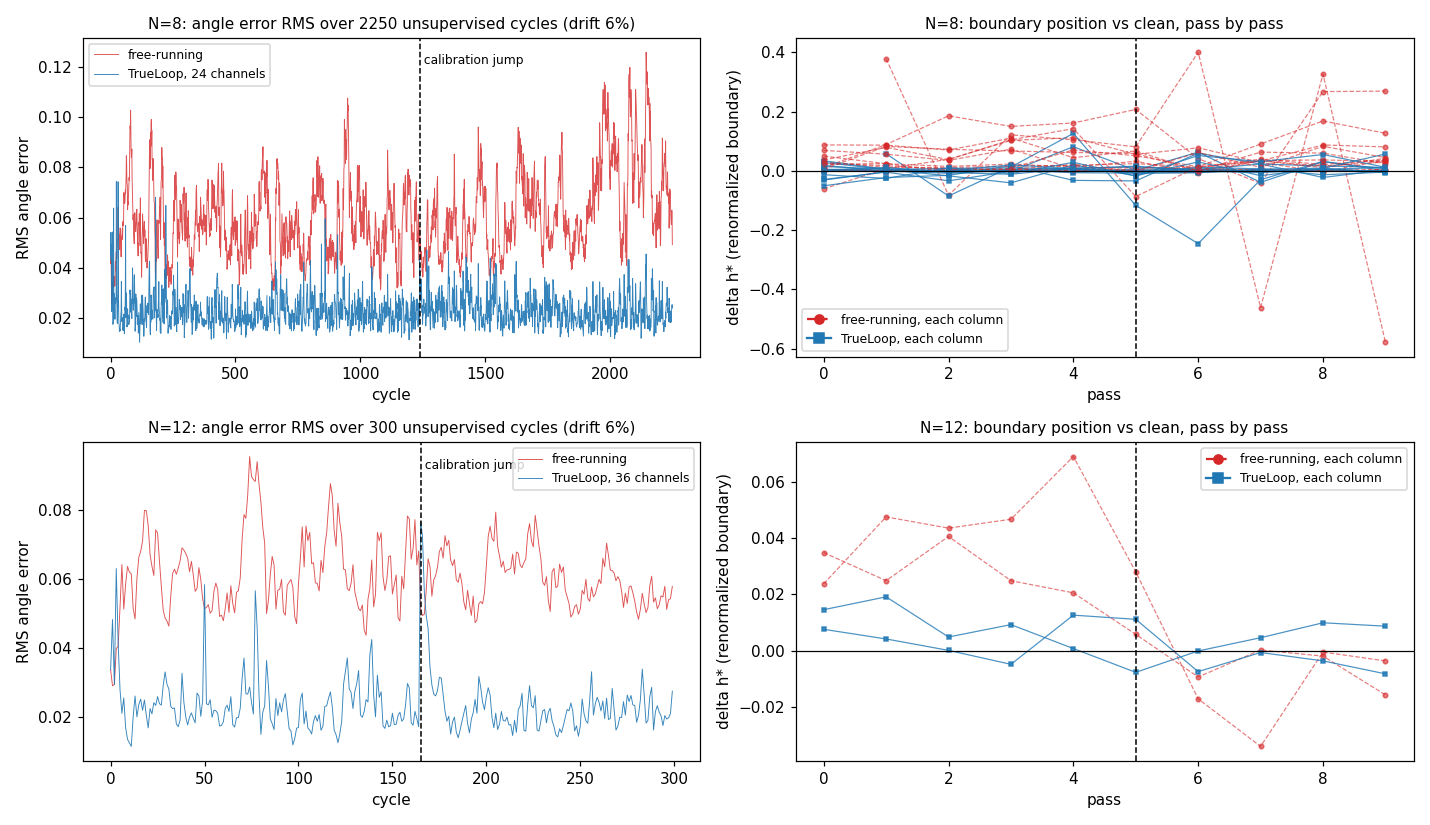

In [11]:
import continuous as CT
CT.SHOTS, CT.AMP = 4000, 3
for n in (8, 12):
    R = pickle.load(open("data/continuous_N%d_p10_r0.06.pkl" % n, "rb"))
    if RECOMPUTE or n == 8:
        t0 = time.perf_counter(); R = CT.run(n, 10, 0.06, 5); print("N=%d re-run live: %.0f s" % (n, time.perf_counter() - t0))
    pts, ks = R["pts"], R["ks"]; b0 = CT.boundaries(R["zz_clean"], pts, ks); passes = R["zz_free"].shape[0]
    sf = np.array([[CT.boundaries(R["zz_free"][p], pts, ks)[k] for k in ks] for p in range(passes)]); sh = np.array([[CT.boundaries(R["zz_held"][p], pts, ks)[k] for k in ks] for p in range(passes)])
    print("N=%d, %d channels, %d cycles: host %.0f us/cycle | angle error RMS free %.3f -> maintained %.3f | pass-to-pass boundary std free %.3f -> maintained %.3f" % (
        n, R["nch"], R["cycles"], R["host_us"], np.sqrt(np.mean(R["res_free"] ** 2)), np.sqrt(np.mean(R["res_held"] ** 2)), np.nanmean(np.nanstd(sf, 0)), np.nanmean(np.nanstd(sh, 0))))
from IPython.display import Image, display; display(Image("figures/continuous_operation.png"))

## 10. Complexity decoupled from the state: $N = 8, 12, 16, 20$
Two things keep continuous hardware in a laboratory. A person has to recalibrate it on a schedule, so it cannot run unsupervised and cannot follow a wander faster than the schedule; or the host has to reconstruct the device's state to correct it, which costs $n^2$ memory and $n^3$ setup and cannot reach high dimension. The quantum state has $2^N$ amplitudes; the host maintains $3N$ channels. If the maintenance layer is what keeps a hybrid system valid, its cost must not scale with the state, or it re-imports the burden that delegation to the device was meant to remove. This section runs the continuous scan of the $\kappa = 0.29$ column at $N = 8, 12, 16$ and $20$, with eight-layer circuits exact to $10^{-3}$ at $N = 12$ (correlators within 0.01 of exact diagonalization) and within 0.14 in the ordered phase at $N = 16$ (eight layers is the ansatz's limit for sixteen sites); the $N = 20$ circuits carry the $N = 16$ angles without re-optimization, which is fine for a maintenance comparison against the same clean circuit. Three arms on one drift trajectory: free-running, an engineer recalibrating every 50 cycles, and the contract in-band. The correction bounds are $[0.85, 1.15]$, chosen so that bounds times drift stays inside the three-fold probe's monotone range; with wider bounds one channel at $N=16$ left that range, learned an inverted slope, and ran to its bound, which is the capture-range rule the appendix states.

  N | state dim | channels | cycles | host us/cycle | state eval (ms) | angle error: free/eng/contract | boundary shift: free/eng/contract
  8 |       256 |       24 |    150 |            56 |              1 | 0.061 / 0.051 / 0.046            | 0.014 / 0.006 / 0.007
 12 |      4096 |       36 |    150 |            85 |              9 | 0.051 / 0.047 / 0.028            | 0.085 / 0.064 / 0.025
 16 |     65536 |       48 |    144 |           129 |            242 | 0.059 / 0.046 / 0.031            | 0.018 / 0.016 / 0.008
 20 |   1048576 |       60 |     18 |           159 |           5240 | 0.043 /   --  / 0.029            | 0.023 /   --  / 0.015

from N=8 to N=20 the state dimension grows 4096x, the classical cost of evaluating the state 8846x, and the host's maintenance cost 2.8x (linear in channels, about 2.6 us per channel).


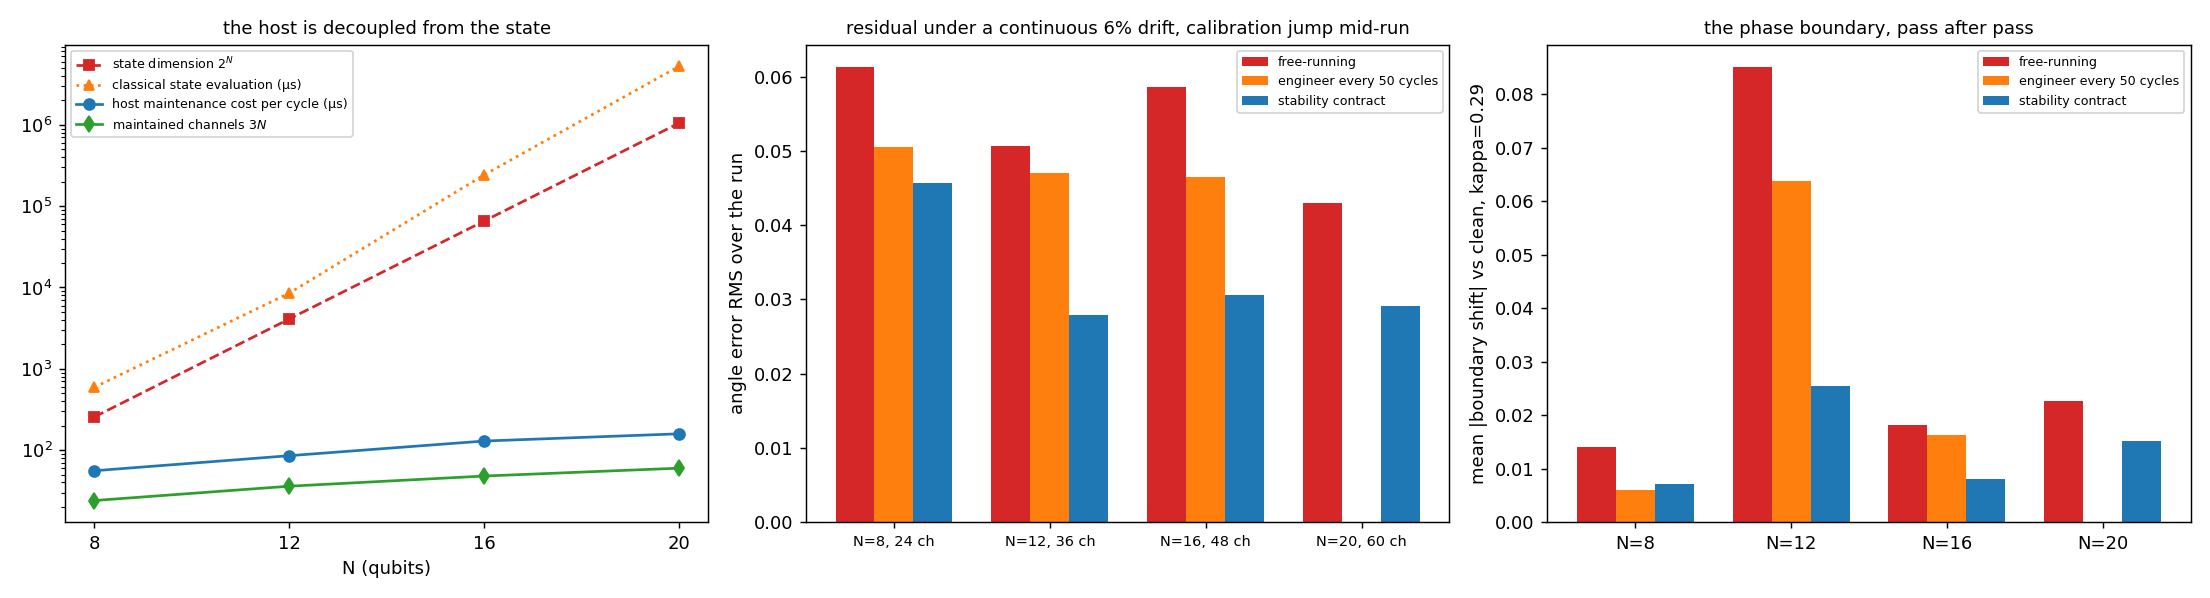

In [12]:
rows = pickle.load(open("data/decoupling_rows.pkl", "rb"))
print("%3s | %9s | %8s | %6s | %13s | %14s | %-26s | %-28s" % ("N", "state dim", "channels", "cycles", "host us/cycle", "state eval (ms)", "angle error: free/eng/contract", "boundary shift: free/eng/contract"))
for r in rows:
    print("%3d | %9d | %8d | %6d | %13.0f | %14.0f | %.3f / %5s / %.3f            | %.3f / %5s / %.3f" % (r[0], r[1], r[2], r[3], r[4], r[5], r[6], ("%.3f" % r[7]) if r[7] == r[7] else "  -- ", r[8], r[9], ("%.3f" % r[10]) if r[10] == r[10] else "  -- ", r[11]))
print("\nfrom N=8 to N=20 the state dimension grows %dx, the classical cost of evaluating the state %dx, and the host's maintenance cost %.1fx (linear in channels, about %.1f us per channel)." % (rows[-1][1] // rows[0][1], int(rows[-1][5] / rows[0][5]), rows[-1][4] / rows[0][4], rows[-1][4] / rows[-1][2]))
display(Image("figures/decoupling.png"))

## 9. Physical interpretation, limitations, and the floating phase
**Which phase is most robust, and why.** Under depolarizing noise both ordered phases lose amplitude, but not equally: at $p = 0.01$ the deep antiphase correlator survives at 0.60 of its clean value and the deep ferromagnet at only 0.37. Both finite-size ground states are cat-like superpositions of their classical patterns, but the ferromagnetic state is prepared by the circuit with more net $X$ rotation from the paramagnet, so more of its correlation is built late in the circuit, after the CNOTs that carry the noise. This is a preparation-circuit statement as much as a Hamiltonian one, and it reverses the naive expectation that the antiphase, needing correlations two sites long, is the fragile one. The paramagnet is trivially robust: noise makes everything look more paramagnetic. Under coherent drift the ranking is different again: the ferromagnetic boundary moves more than the antiphase boundary because $C_2$ is steeper in $h$ there.

**In the language of the model.** Depolarizing shortens every correlation length uniformly, so order parameters shrink without the boundaries moving; a ratio observable sees the boundary until the correlation length is below two sites. Coherent drift changes the effective Hamiltonian the circuit prepares, shifting where frustration ($\kappa$) and field ($h$) balance; that is a real boundary shift. Rescaling fixes the first, maintenance fixes the second, and together they separate what calibration can recover from what decoherence costs.

**Floating phase.** Not resolved. At $N = 8$ the incommensurate floating phase between the antiphase and paramagnet cannot be distinguished from the antiphase boundary region, and this study's threshold classifier would not resolve it under noise either; the two points near $\kappa \approx 0.6$ where the variational state is 0.3 off in $C_2$ are in exactly this region, which is the finite-size difficulty the handout anticipates.

**Limitations.** $N = 8$ periodic; a four-layer ansatz at $N = 8$ that is exact except at the degenerate KT-line point noted in Section 3, and eight-layer circuits exact to $10^{-3}$ at $N = 12$ but at their limit by $N = 16$; depolarizing modelled after CNOTs only, at a depth (128 CNOTs) where $p = 0.01$ already halves the signal, so the depth-times-$p$ product, not $p$, is the relevant parameter; and a drift model whose per-cycle wander sets the maintenance residual at about 0.4 of free-running. One product boundary found on the way: with link signs declared and a 4,000-shot probe, the contract's one-time slope identification mis-read up to ten channels under 6% drift and held them; letting the preflight learn the signs removed the failure, and that configuration is the one used here.


## References and resources used
1. Quantum Coalition, QSITE 2026 Scientific Track handout and starter kit: https://github.com/benmcdonough20/QSITE-2026-QuantumCoalition (Hamiltonian builder, observables, analytic lines; `starter_kit/` is a copy).
2. PennyLane demo "ANNNI Phase Detection": https://pennylane.ai/qml/demos/tutorial_annni (source of the Ising and Kosterlitz-Thouless boundary formulas used as reference lines).
3. PennyLane challenge "A Noisy Heisenberg Model": https://pennylane.ai/challenges/heisenberg_model (the depolarizing-after-every-CNOT convention).
4. V. Bergholm et al., "PennyLane: Automatic differentiation of hybrid quantum-classical computations," arXiv:1811.04968 (2018). PennyLane 0.45.1.
5. W. Selke, "The ANNNI model: theoretical analysis and experimental application," Physics Reports 170, 213 (1988).
6. M. S. Leibel, "A Stability Contract for Scalable Hybrid Computing: Minimal Sufficient Control of Component-Observable Hardware," Preprints 202609.1101 (2026), doi:10.20944/preprints202609.1101.v1, under review at IEEE Transactions on Computers. Method and bounds of the maintenance layer; the TrueLoop v3.1.0 evaluation build (NEOTECH Inc.) is included under its evaluation licence.
7. NumPy, SciPy, Matplotlib, nbformat/nbconvert.
